# Random Sample vs Stratified Sample

This notebook compares two ways to sample from the rodent dataset:
- A **random sample** from the full dataset
- A **stratified sample** with the same number of observations from each species

The goal is to understand the tradeoff between a simple random sampling process and a more calculated sampling process. Random sampling is easier to run, but it can miss or underrepresent rare species. Stratified sampling requires more planning, but it gives each species equal representation in the sample.

A useful way to compare these methods is to start with the the full dataset. Once we know which species, sexes, plots, and seasons dominate the full dataset, we can see what each sampling method preserves and what each method distorts.

Both sampling methods use a random seed so the results are reproducible, in this case *123*.

---

## Load the data

This cell reads the merged project dataset so we can sample from the full set of rodent observations.

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 123
OBSERVATIONS_PER_SPECIES = 40

df = pd.read_csv("../../output/merged_full.csv")
df.head()

,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


The merged dataset includes time columns, species information, plot information, and measurement columns. For this lesson, the most important columns are **species_id** and **species_name**, because the stratified sample will intentionally take the same number of observations from each species.

## Prepare the sampling dataset

This cell keeps the columns needed for the sampling comparison.

In [232]:
sample_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'genus',
    'taxa',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'genus', 'taxa', 'plot_type']:
    sample_df[col] = sample_df[col].astype('string').str.strip()

sample_df = sample_df.dropna(subset=['species_id', 'species_name']).copy()

sample_df.head()

,record_id,year,month,species_id,species_name,sex,genus,taxa,plot_type,hindfoot_length,weight
0,63,1977,8,DM,merriami,M,Dipodomys,Rodent,Long-term Krat Exclosure,35.0,40.0
1,64,1977,8,DM,merriami,M,Dipodomys,Rodent,Rodent Exclosure,37.0,48.0
2,65,1977,8,DM,merriami,F,Dipodomys,Rodent,Control,34.0,29.0
3,66,1977,8,DM,merriami,F,Dipodomys,Rodent,Control,35.0,46.0
4,67,1977,8,DM,merriami,M,Dipodomys,Rodent,Rodent Exclosure,35.0,36.0


## Start with the full dataset truth

Before sampling anything, we should inspect the full dataset. The full dataset shows the natural structure of the observations. Which species are common, which species are rare, and whether other grouping variables such as **sex**, **plot_type**, **month**, and **year** are evenly distributed.Usually the dataset is not uniform, so sampling choices matter.

In [233]:
print(f"There are {len(sample_df)} total observations in the Full Dataset")
print(f"There are {sample_df['species_id'].nunique()} types of species")
print(f"There are {sample_df['sex'].nunique(dropna=False)} categories of sex")
print(f"There are {sample_df['plot_type'].nunique(dropna=False)} types of plots")
print(f"The range of years are from {sample_df['year'].min()} to {sample_df['year'].max()}")

There are 70917 total observations in the Full Dataset
There are 24 types of species
There are 2 categories of sex
There are 6 types of plots
The range of years are from 1977 to 2025


This is the baseline that both samples should be compared against. If the goal is to estimate the whole population, a sample should look similar to this full dataset. If the goal is to compare groups, a sample may intentionally look different.

## Count observations by species

Before stratified sampling, we need to know whether each species has enough records. A stratified sample with 40 observations per species can only include species that have at least 40 observations available.

This table also shows the species imbalance in the full dataset. A few species make up a large share of the rows, while rare species contribute very few observations.

In [234]:
species_counts = (
    sample_df.groupby(['species_id', 'species_name'], as_index=False)
    .size()
    .rename(columns={'size': 'full_dataset_count'})
    .sort_values('full_dataset_count', ascending=False)
)

species_counts['full_dataset_percent'] = (
    species_counts['full_dataset_count'] / species_counts['full_dataset_count'].sum()
)

species_counts

,species_id,species_name,full_dataset_count,full_dataset_percent
15,PP,penicillatus,18565,0.261785
1,DM,merriami,17546,0.247416
8,PB,baileyi,10427,0.147031
2,DO,ordii,5459,0.076977
6,OT,torridus,4320,0.060916
18,RM,megalotis,3531,0.049791
9,PE,eremicus,2775,0.039130
3,DS,spectabilis,2094,0.029527
10,PF,flavus,1991,0.028075
5,OL,leucogaster,1330,0.018754


The full dataset is not balanced across species. Some species have thousands of observations, while others have far fewer. This imbalance is the main reason random and stratified samples can produce different results.

A random sample usually preserves these natural proportions. A stratified sample intentionally changes them so every species gets enough representation.

## Create the sampling frame

This cell keeps only the species with enough observations for the equal-size stratified sample. This makes the two sampling methods easier to compare because both samples will use the same total sample size.

In [235]:
eligible_species = species_counts.loc[
    species_counts['full_dataset_count'] >= OBSERVATIONS_PER_SPECIES,
    'species_id'
]

sampling_frame = sample_df[sample_df['species_id'].isin(eligible_species)].copy()

n_species = sampling_frame['species_id'].nunique()
total_sample_size = n_species * OBSERVATIONS_PER_SPECIES


print(f"When searching for {OBSERVATIONS_PER_SPECIES} observations per species...\n")
print(f"There will be {n_species} species sampled")
print(f"There will be {total_sample_size} total observations")

When searching for 40 observations per species...

There will be 20 species sampled
There will be 800 total observations


The sampling frame is the population that both methods will sample from. Using the same frame and the same total sample size lets the comparison focus on the sampling strategy instead of differences in sample size.

## Randomly sample from the full sampling frame

This cell takes one random sample from the full sampling frame. The sample size matches the stratified sample size, and the random seed is set to *123*.

In [236]:
random_sample = sampling_frame.sample(
    n=total_sample_size,
    random_state=RANDOM_SEED
).reset_index(drop=True)

random_sample.head()

,record_id,year,month,species_id,species_name,sex,genus,taxa,plot_type,hindfoot_length,weight
0,49443,2008,4,SF,fulviventer,F,Sigmodon,Rodent,Control,27.0,92.0
1,67816,2017,9,PP,penicillatus,F,Chaetodipus,Rodent,Rodent Exclosure,21.0,19.0
2,18746,1991,6,PP,penicillatus,F,Chaetodipus,Rodent,Spectab exclosure,16.0,18.0
3,74984,2023,3,PP,penicillatus,M,Chaetodipus,Rodent,Long-term Krat Exclosure,20.0,23.0
4,38697,2004,2,DM,merriami,F,Dipodomys,Rodent,Control,37.0,43.0


A random sample is simple because it does not require us to plan how many records to take from each species. Each row in the sampling frame has the same chance of being selected.

If the random sample misses a species, that species cannot be analyzed in the sample. If the random sample includes only a few observations for a species, the species-level average may be unstable.

## Stratify the sample by species

This cell samples the same number of observations from every eligible species. The strata are defined by *species_id*, and the random seed is also set to *123*.

In [237]:
stratified_sample = (
    sampling_frame
    .groupby('species_id', group_keys=False)
    .sample(n=OBSERVATIONS_PER_SPECIES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

stratified_sample.head()

,record_id,year,month,species_id,species_name,sex,genus,taxa,plot_type,hindfoot_length,weight
0,61414,2015,3,BA,taylori,F,Baiomys,Rodent,Control,13.0,12.0
1,62019,2015,4,BA,taylori,F,Baiomys,Rodent,Long-term Krat Exclosure,13.0,14.0
2,61108,2015,2,BA,taylori,M,Baiomys,Rodent,Short-term Krat Exclosure,13.0,8.0
3,62423,2015,5,BA,taylori,M,Baiomys,Rodent,Rodent Exclosure,13.0,7.0
4,64904,2016,3,BA,taylori,M,Baiomys,Rodent,Rodent Exclosure,12.0,8.0


A stratified sample is more calculated. It requires us to know the species groups first, then sample within each species group. This creates a balanced sample by species, even when the full dataset is not balanced.

## Compare species representation

This cell compares how many observations each species contributes to the full sampling frame, the random sample, and the stratified sample. It includes both raw counts and proportions so the representation and distribution comparisons are in one table.

In [238]:
representation_df = pd.DataFrame({
    'full_dataset_count': sampling_frame['species_id'].value_counts(),
    'random_sample_count': random_sample['species_id'].value_counts(),
    'stratified_sample_count': stratified_sample['species_id'].value_counts(),
    'full_dataset_percent': sampling_frame['species_id'].value_counts(normalize=True),
    'random_sample_percent': random_sample['species_id'].value_counts(normalize=True),
    'stratified_sample_percent': stratified_sample['species_id'].value_counts(normalize=True)
}).fillna(0)

count_columns = ['full_dataset_count', 'random_sample_count', 'stratified_sample_count']
representation_df[count_columns] = representation_df[count_columns].astype(int)

representation_df = representation_df.sort_values('full_dataset_count', ascending=False)
representation_df


,full_dataset_count,random_sample_count,stratified_sample_count,full_dataset_percent,random_sample_percent,stratified_sample_percent
species_id,,,,,,
PP,18565,211,40,0.26184,0.26375,0.05
DM,17546,198,40,0.247468,0.2475,0.05
PB,10427,111,40,0.147062,0.13875,0.05
DO,5459,69,40,0.076994,0.08625,0.05
OT,4320,43,40,0.060929,0.05375,0.05
RM,3531,42,40,0.049801,0.0525,0.05
PE,2775,35,40,0.039139,0.04375,0.05
DS,2094,23,40,0.029534,0.02875,0.05
PF,1991,16,40,0.028081,0.02,0.05


The random sample usually follows the shape of the full dataset. Species with many observations in the full dataset tend to have many observations in the random sample, while rare species may have very few.

The stratified sample has the same number of observations for every species because that rule was built into the sampling process.

The count columns show species coverage, while the percent columns show distribution. *random_sample_percent* should be close to *full_dataset_percent*, while *stratified_sample_percent* should not be close to *full_dataset_percent*. That difference is not a mistake. It shows that stratified sampling is answering a different kind of question.

## Visualize the sample counts

This chart makes the difference between the random sample and the stratified sample easier to see.

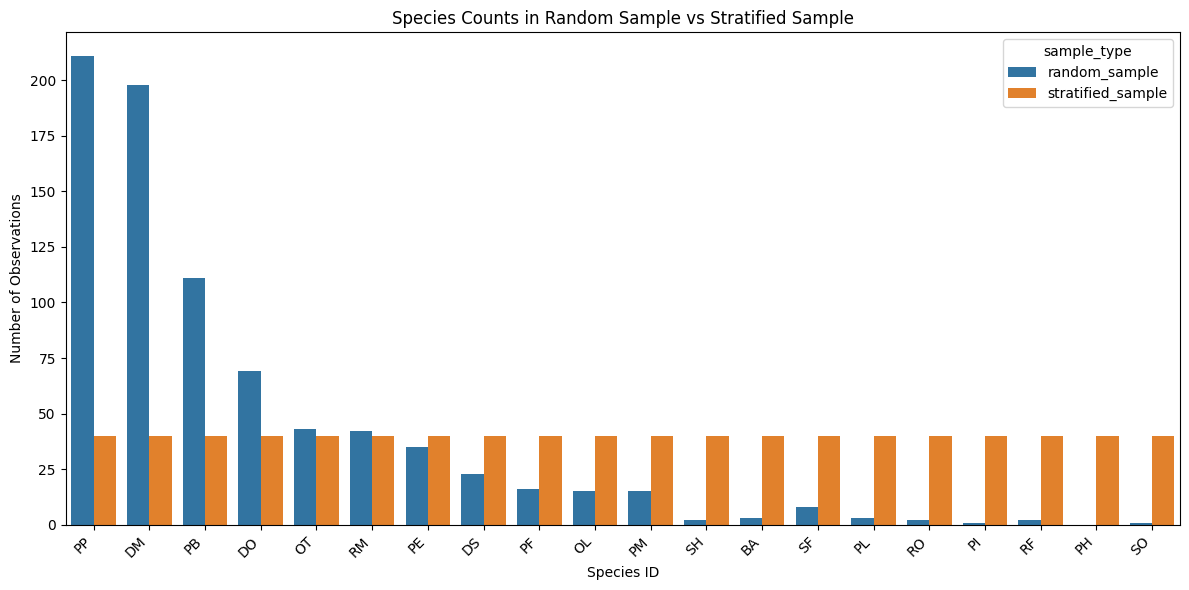

In [239]:
# FIG 4.1

sample_counts = (
    representation_df[['random_sample_count', 'stratified_sample_count']]
    .reset_index(names='species_id')
    .melt(
        id_vars='species_id',
        var_name='sample_type',
        value_name='n_observations'
    )
)

sample_counts['sample_type'] = sample_counts['sample_type'].str.replace('_count', '', regex=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sample_counts,
    x='species_id',
    y='n_observations',
    hue='sample_type'
)
plt.xticks(rotation=45, ha='right')
plt.title('Species Counts in Random Sample vs Stratified Sample')
plt.xlabel('Species ID')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()


The random sample is uneven because it reflects the uneven population. The stratified sample is flat because it was designed to include exactly 40 observations per species.

## Compare measurement summaries

This cell compares the average hindfoot length and average weight across the full sampling frame and both samples.

In [240]:
summary_df = pd.DataFrame({
    'dataset': ['full_dataset', 'random_sample', 'stratified_sample'],
    'number_observations': [len(sampling_frame), len(random_sample), len(stratified_sample)],
    'number_species': [
        sampling_frame['species_id'].nunique(),
        random_sample['species_id'].nunique(),
        stratified_sample['species_id'].nunique()
    ],
    'mean_hindfoot_length': [
        sampling_frame['hindfoot_length'].mean(),
        random_sample['hindfoot_length'].mean(),
        stratified_sample['hindfoot_length'].mean()
    ],
    'median_hindfoot_length': [
        sampling_frame['hindfoot_length'].median(),
        random_sample['hindfoot_length'].median(),
        stratified_sample['hindfoot_length'].median()
    ],
    'mean_weight': [
        sampling_frame['weight'].mean(),
        random_sample['weight'].mean(),
        stratified_sample['weight'].mean()
    ],
    'median_weight': [
        sampling_frame['weight'].median(),
        random_sample['weight'].median(),
        stratified_sample['weight'].median()
    ]
})

summary_df

,dataset,number_observations,number_species,mean_hindfoot_length,median_hindfoot_length,mean_weight,median_weight
0,full_dataset,70902,20,26.934529,25.0,32.445432,27.0
1,random_sample,800,19,26.981250,25.0,32.522500,28.0
2,stratified_sample,800,20,23.780000,21.0,34.925000,25.0


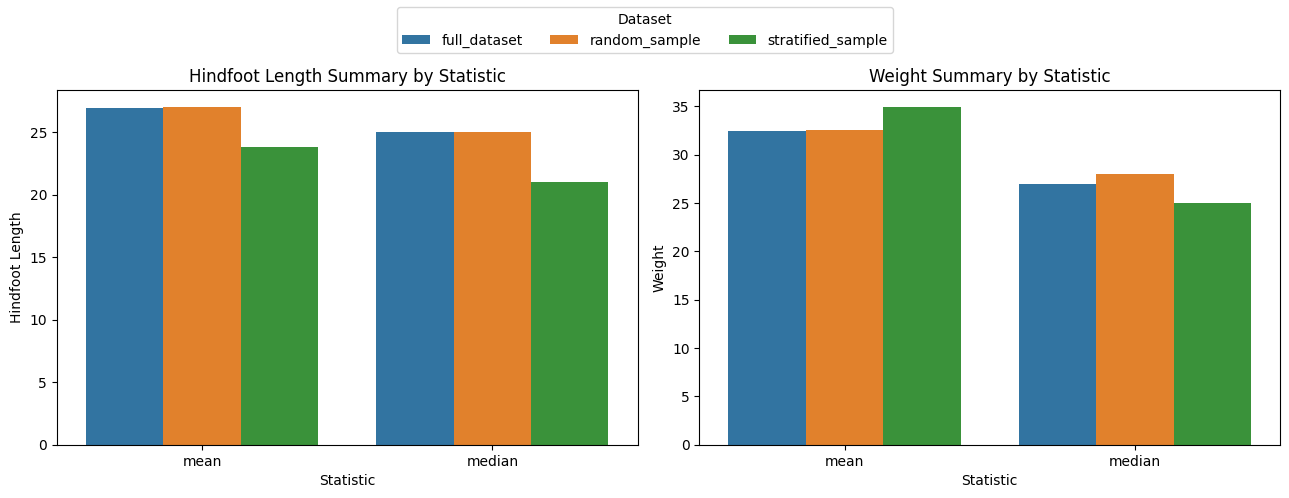

In [241]:
summary_plot_df = summary_df.melt(
    id_vars='dataset',
    value_vars=[
        'mean_hindfoot_length',
        'median_hindfoot_length',
        'mean_weight',
        'median_weight'
    ],
    var_name='metric',
    value_name='value'
)

summary_plot_df['statistic'] = summary_plot_df['metric'].str.extract(r'^(mean|median)')
summary_plot_df['measurement'] = summary_plot_df['metric'].str.replace(r'^(mean|median)_', '', regex=True)

hindfoot_plot_df = summary_plot_df[
    summary_plot_df['measurement'] == 'hindfoot_length'
].copy()

weight_plot_df = summary_plot_df[
    summary_plot_df['measurement'] == 'weight'
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=hindfoot_plot_df,
    x='statistic',
    y='value',
    hue='dataset',
    ax=axes[0]
)
axes[0].set_title('Hindfoot Length Summary by Statistic')
axes[0].set_xlabel('Statistic')
axes[0].set_ylabel('Hindfoot Length')

sns.barplot(
    data=weight_plot_df,
    x='statistic',
    y='value',
    hue='dataset',
    ax=axes[1]
)
axes[1].set_title('Weight Summary by Statistic')
axes[1].set_xlabel('Statistic')
axes[1].set_ylabel('Weight')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles, labels, title='Dataset', loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The random sample is designed to estimate the overall dataset. The stratified sample is designed to compare species more evenly. These are different goals, so the summaries can be different even when the total sample sizes are the same.

## Compare species-level averages

Stratified sampling shines when the question is about comparing groups. This cell calculates species-level mean weight for both samples and includes the sample count for each species.

In [ ]:
random_species_summary = (
    random_sample.groupby('species_id')
    .agg(
        random_number=('weight', 'size'),
        random_mean_weight=('weight', 'mean')
    )
)

stratified_species_summary = (
    stratified_sample.groupby('species_id')
    .agg(
        stratified_number=('weight', 'size'),
        stratified_mean_weight=('weight', 'mean')
    )
)

species_level_comparison = random_species_summary.join(stratified_species_summary, how='outer')
species_level_comparison = species_level_comparison[['random_number', 'stratified_number', 'random_mean_weight', 'stratified_mean_weight']]
species_level_comparison

,random_number,stratified_number,random_mean_weight,stratified_mean_weight
species_id,,,,
BA,3.0,40,7.666667,9.450
DM,198.0,40,44.707071,43.225
DO,69.0,40,47.927536,46.475
DS,23.0,40,115.043478,117.025
OL,15.0,40,29.866667,30.425
OT,43.0,40,24.000000,24.500
PB,111.0,40,31.873874,32.200
PE,35.0,40,21.885714,22.425
PF,16.0,40,8.250000,8.325


Notice that the stratified sample gives every eligible species the same number of rows. The random sample may still be better for estimating the overall population, but it can leave some species with too few rows for a confident species-level comparison.

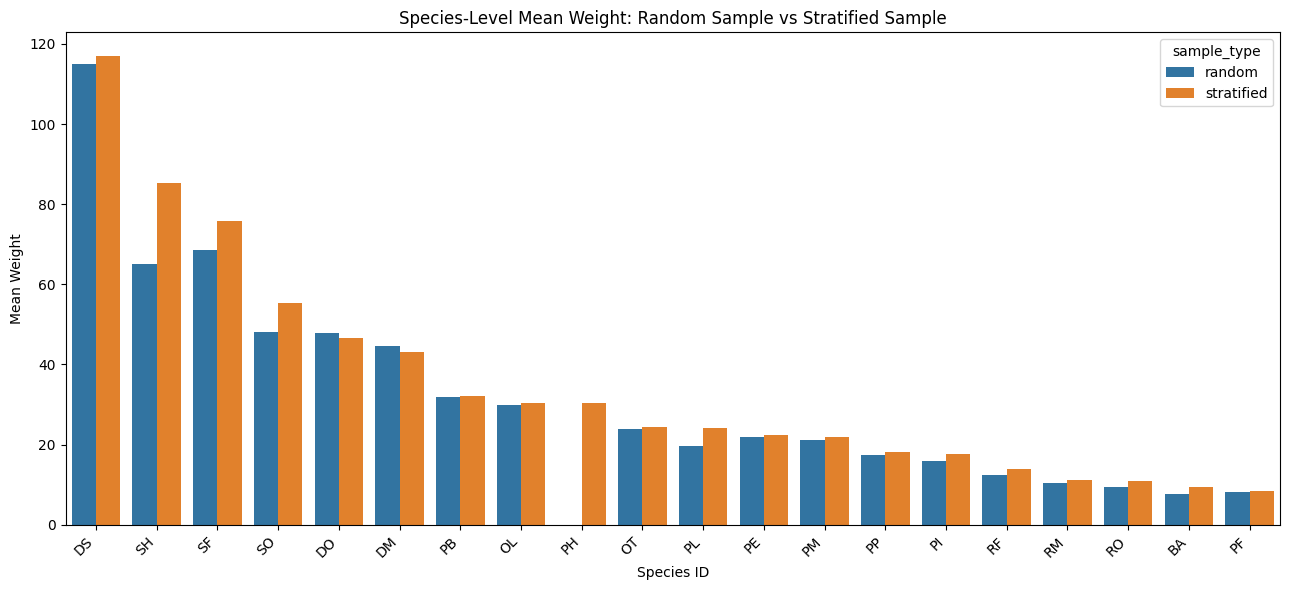

In [243]:
# FIG 4.3

species_weight_plot_df = (
    species_level_comparison
    .reset_index()
    .sort_values('stratified_mean_weight', ascending=False)
    .melt(
        id_vars='species_id',
        value_vars=['random_mean_weight', 'stratified_mean_weight'],
        var_name='sample_type',
        value_name='mean_weight'
    )
)

species_weight_plot_df['sample_type'] = (
    species_weight_plot_df['sample_type']
    .str.replace('_mean_weight', '', regex=False)
    .str.replace('_', ' ', regex=False)
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=species_weight_plot_df,
    x='species_id',
    y='mean_weight',
    hue='sample_type'
)
plt.xticks(rotation=45, ha='right')
plt.title('Species-Level Mean Weight: Random Sample vs Stratified Sample')
plt.xlabel('Species ID')
plt.ylabel('Mean Weight')
plt.tight_layout()
plt.show()


## Choose the sample based on the question

If the question is **What is the average weight of rodents overall?**, a random sample is usually the better choice because it preserves the natural population proportions.

If the question is **How does weight differ across species?**, a stratified sample is usually the better choice because it ensures enough observations from each species.

The calculated sample gives more control over representation, but that control comes with extra setup. We need to define the species groups, decide the number of observations per species, and remove species that do not have enough records for the rule.

## Conclusion

**Random Sample** 
- useful when the goal is to cheaply and simply estimate the full dataset. 
- tends to include more observations from common species.

**Stratified Sample** 
- useful when the goal is to compare groups more evenly. 
- protects rare species from being overwhelmed by common species in the sample.

- The best sampling method depends on the question. If the question is about the overall population, a random sample may be better. If the question is about comparing species, a stratified sample may be better.

A random sample is best for estimating the overall population because it preserves natural proportions. A stratified sample is best for comparing groups because it ensures each group is represented. The choice of sampling method depends on the question being asked, not just the dataset.